# Name:Ritika lund
# CMS-ID:023-24-0262
# Section:H
# Github:https://github.com/Ritika-Lund/Machine-learning-Lab.git
# Kaggle:https://www.kaggle.com/ritikalund
# Dataset:Telco churn dataset
# Dataset source:https://www.kaggle.com/datasets/vedatgul/telco-churn-dataset

In [43]:
# impporting libraries
import pandas as pd
import numpy as np

# Part 1:Problem Definition & Dataset Verification

# Task 1:

In [44]:
df=pd.read_csv("clean_churn.csv")
print("shape of cleaned dataset :",df.shape)
print("\ndata types of cleaned dataset :\n",df.dtypes)
print("\nmissing values :\n",df.isnull().sum())
print("\nduplicated values before :",df.duplicated().sum())
df=df.drop_duplicates()
print("duplicated values after :",df.duplicated().sum())
print("Shape after removing duplicates:", df.shape)

shape of cleaned dataset : (7043, 20)

data types of cleaned dataset :
 gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

missing values :
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paper

# interpretation of task 1

The cleaned Telco Customer Churn dataset was successfully loaded and verified. After removing the duplicate rows, the dataset contains no duplicate records and no missing values. The column data types were also checked, confirming that the dataset is ready for the feature and target preparation stage.

# Task 2


we are predicting that whether the customers of teleco company will churn or not based on the their data .It matters alot to buisness as if the company is able to predict which customers are probably going to churn in future it can take actions to stop them from leaving.


# Part 2: Feature & Target Preparation 

# Task 3

In [45]:
print("checking if any identifier is still present in dataset :\n",df.columns.tolist())
y = df["Churn"].map({"No": 0, "Yes": 1})
# Define features
X = df.drop(columns=["Churn"])
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget values:")
print(y.value_counts())

checking if any identifier is still present in dataset :
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
X shape: (7021, 19)
y shape: (7021,)

Target values:
Churn
0    5164
1    1857
Name: count, dtype: int64


# Task 3 interpretation

The Churn column was separated as the target variable y and encoded as 0 for No and 1 for Yes by using manual mapping. The remaining 19 columns were assigned to X as the input features, and no identifier column such as customerID remains in the dataset. The target contains 5,164 non-churned customers and 1,857 churned customers, showing that the classes are imbalanced.

# Task 4

In [46]:
categorical_cols=X.select_dtypes(include=["object","str"]).columns
print("Categorical columns: ")
print(categorical_cols)
X=pd.get_dummies(X,columns=categorical_cols,dtype=int)
print("New X shape after one-hot encoding: ",X.shape)


Categorical columns: 
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')
New X shape after one-hot encoding:  (7021, 45)


# Task 4 interpretation
One-hot encoding was used to convert the categorical features into numeric form using pd.get_dummies(). This method creates a separate binary column for each category and avoids imposing an artificial numerical order on categories such as contract type, internet service, or payment method.

# Task 5 

In [47]:
print("Data types after encoding:")
print(X.dtypes)
print("\nMissing values in X: " ,X.isnull().sum().sum())

Data types after encoding:
SeniorCitizen                                int64
tenure                                       int64
MonthlyCharges                             float64
TotalCharges                               float64
gender_Female                                int64
gender_Male                                  int64
Partner_No                                   int64
Partner_Yes                                  int64
Dependents_No                                int64
Dependents_Yes                               int64
PhoneService_No                              int64
PhoneService_Yes                             int64
MultipleLines_No                             int64
MultipleLines_No phone service               int64
MultipleLines_Yes                            int64
InternetService_DSL                          int64
InternetService_Fiber optic                  int64
InternetService_No                           int64
OnlineSecurity_No                            int64
Onli

# Part 3: Train/Test split

# Task 6

In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

# Task 6 interpretation
The dataset was divided into 80% training data and 20% test data using train_test_split. Stratification was used because the Churn target is imbalanced, with more customers who did not churn than customers who churned. Using stratify=y helps preserve the original class proportions in both the training and test sets, making the evaluation more representative.

# Task 7

In [49]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5616, 45)
X_test: (1405, 45)
y_train: (5616,)
y_test: (1405,)


# Task 7 interpretation
The training set contains 5,616 customers with 45 features, while the test set contains 1,405 customers with the same 45 features. The corresponding target arrays contain 5,616 and 1,405 Churn labels respectively. The split accounts for all 7,021 customers.

# Part 4: Baseline Decision Tree

# Task 8

In [50]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)
print("Training predictions :",y_train_pred)
print("Testing predictions :",y_test_pred)

Training predictions : [1 0 0 ... 1 0 0]
Testing predictions : [1 1 1 ... 0 0 0]


# Task 8 interpretation
An unrestricted Decision Tree classifier was trained using the training data with random_state=42. Predictions were generated for both the training and test sets. The training predictions show how the model classifies the data it learned from, while the test predictions represent its performance on unseen data. 

# Task 9

In [51]:
print("Tree depth:", model.get_depth())

Tree depth: 24


# Task 9 interpretation
The baseline Decision Tree has a maximum depth of 24. This indicates that the unrestricted tree has learned a relatively complex set of decision rules.

# Part 5: Model Evaluation

# Task 10

In [52]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
print("Test Accuracy :", accuracy)
print("Test Precision:", precision)
print("Test Recall   :", recall)
print("Test F1-score :", f1)

Test Accuracy : 0.7153024911032029
Test Precision: 0.4648241206030151
Test Recall   : 0.49731182795698925
Test F1-score : 0.4805194805194805


# Task 10 interpretation
The baseline Decision Tree achieved a test accuracy of 71.53%. However, its precision, recall, and F1-score were considerably lower, at 46.48%, 49.73%, and 48.05%, respectively. Since the Churn classes are imbalanced, accuracy alone is not sufficient to evaluate the model. The recall of 49.73% indicates that the model identifies approximately half of the customers who actually churn, so further investigation and model tuning are needed.

# Task 11

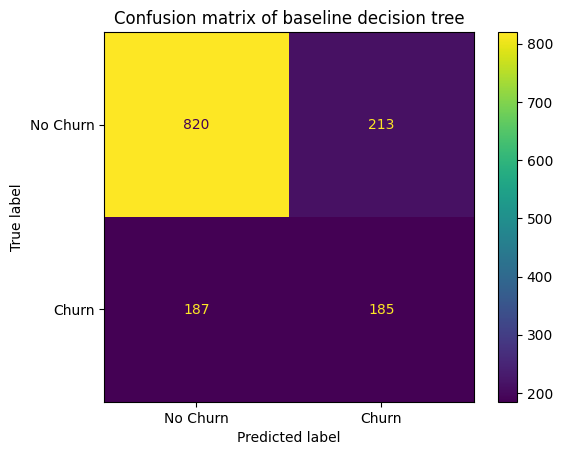

Confusion matrix :
[[820 213]
 [187 185]]


In [53]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_test_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Churn","Churn"])
disp.plot()
plt.title("Confusion matrix of baseline decision tree")
plt.show()
print("Confusion matrix :")
print(cm)

# Task 11 interpretaion
The confusion matrix shows that the model correctly classified 820 non-churning customers and 185 churning customers. It incorrectly predicted churn for 213 customers who did not actually churn, while 187 customers who actually churned were incorrectly predicted as non-churning. Therefore, the model successfully identified 185 out of 372 actual churners but missed 187 of them. This shows that the baseline model has difficulty identifying a substantial number of customers who are likely to churn.

# Task 12
Churn target is imbalanced as found in previous lab,that is why accuracy should not be used as the only evaluation metric. Recall is particularly important because it measures how many actual churners the model successfully identifies, while precision shows how reliable the model's churn predictions are. The F1-score is also useful because it balances precision and recall. Therefore, recall and F1-score should receive more attention than accuracy alone when evaluating this churn model.

# Part 6: Overfitting Investigation 

# Task 13

In [54]:
train_accuracy=accuracy_score(y_train,y_train_pred)
test_accuracy=accuracy_score(y_test,y_test_pred)
print("Training accuracy : ",round((train_accuracy),3))
print("Testing accuracy : ",round(test_accuracy,3))
print("Accuracy Gap:", round((train_accuracy - test_accuracy),3))


Training accuracy :  0.998
Testing accuracy :  0.715
Accuracy Gap: 0.282


# Task 13 interpretaion
The baseline decision tree shows an accuracy gap of 0.28(28%) between the training and test accuracy.This is a large difference ,indicating that the model is performing very well on training data but poorly on testing data.Therefore the unrestriced tree shows evidence of overfitting. Its depth of 24 allows it to learn very detailed patterns in the training data, which may not generalize well to new customers.

# Task 14

In [55]:
depths=[2,3,4,5,6,8,10,None]
results=[]
for depth in depths:
    tree=DecisionTreeClassifier(max_depth=depth,random_state=42)
    tree.fit(X_train,y_train)
    test_pred=tree.predict(X_test)
    train_pred=tree.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    results.append({
        "max_depth": depth,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    })
results_df=pd.DataFrame(results)
print(results_df)

   max_depth  train_accuracy  test_accuracy
0        2.0        0.764245       0.755872
1        3.0        0.792557       0.786477
2        4.0        0.798433       0.786477
3        5.0        0.802172       0.794306
4        6.0        0.813925       0.793594
5        8.0        0.841346       0.780783
6       10.0        0.879274       0.775801
7        NaN        0.997685       0.715302


# Task 14 interpretation
Decision Trees with different depths were trained and evaluated on both the training and test sets. Training accuracy generally increased as the maximum depth increased, reaching 99.77% for the unrestricted tree. However, test accuracy improved only up to a maximum depth of 5, where it reached 79.43%, and then decreased as the tree became deeper. This suggests that increasing tree complexity beyond this point causes the model to fit the training data more closely without improving its performance on unseen data.


# Task 15

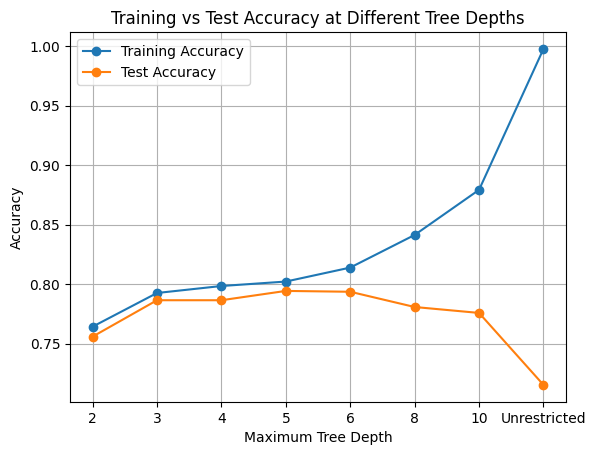

In [56]:
plot_df = results_df.copy()

plot_df["depth_label"] = plot_df["max_depth"].apply(
    lambda x: "Unrestricted" if pd.isna(x) else str(int(x))
)

plt.plot(
    plot_df["depth_label"],
    plot_df["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    plot_df["depth_label"],
    plot_df["test_accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy at Different Tree Depths")
plt.legend()
plt.grid(True)
plt.show()

# Task 15 interpretation
The training accuracy increases as the maximum tree depth increases, showing that deeper trees can fit the training data more closely. However, test accuracy improves only up to a maximum depth of 5, where it reaches 79.43%. After depth 5, test accuracy gradually decreases while training accuracy continues to increase. This pattern indicates increasing overfitting as the tree becomes deeper. The unrestricted tree shows the strongest overfitting, with very high training accuracy but substantially lower test accuracy.

# Part 7: Model Selection, Feature Importance & Interpretation

# Task 16
Based on the comparison of different tree depths, a maximum depth of 5 was selected for the final Decision Tree. It achieved the highest test accuracy of 79.43% among the tested depths while maintaining a small difference between training accuracy (80.22%) and test accuracy. Deeper trees increased training accuracy but caused test accuracy to decline, indicating increasing overfitting. Therefore, depth 5 provides the best balance between performance and generalization based on the tested values.

# Task 17

In [57]:
final_model=DecisionTreeClassifier(max_depth=5,random_state=42)
final_model.fit(X_train,y_train)
final_train_pred=final_model.predict(X_train)
final_test_pred=final_model.predict(X_test)

final_accuracy = accuracy_score(y_test, final_test_pred)
final_precision = precision_score(y_test, final_test_pred)
final_recall = recall_score(y_test, final_test_pred)
final_f1 = f1_score(y_test, final_test_pred)

print("Final Model Metrics:")
print("Accuracy :", round(final_accuracy,3))
print("Precision:", round(final_precision,3))
print("Recall   :", round(final_recall,3))
print("F1-score :", round(final_f1,3))

Final Model Metrics:
Accuracy : 0.794
Precision: 0.62
Recall   : 0.575
F1-score : 0.597


# Task 17 interpretation
The selected Decision Tree with a maximum depth of 5 achieved 79.40% accuracy, 62.00% precision, 57.50% recall, and a 59.70% F1-score on the test set. Compared with the unrestricted baseline, the selected model improved all four evaluation metrics. In particular, precision increased from 46.48% to 62.00%, while recall increased from 49.73% to 57.50%. This indicates that limiting the tree depth reduced overfitting and improved the model's performance.

# Task 18

In [58]:
entropy_model = DecisionTreeClassifier(
    max_depth=5,
    criterion="entropy",
    random_state=42
)
entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

entropy_accuracy = accuracy_score(y_test, entropy_pred)
entropy_precision = precision_score(y_test, entropy_pred)
entropy_recall = recall_score(y_test, entropy_pred)
entropy_f1 = f1_score(y_test, entropy_pred)

print("Entropy Model Metrics:")
print("Accuracy :", round(entropy_accuracy,3))
print("Precision:",  round(entropy_precision,3))
print("Recall   :",  round(entropy_recall,3))
print("F1-score :",  round(entropy_f1,3))

Entropy Model Metrics:
Accuracy : 0.791
Precision: 0.602
Recall   : 0.621
F1-score : 0.611


# Task 18 interpretation
The Decision Tree was retrained using the entropy criterion while keeping the maximum depth at 5. The entropy model achieved 79.10% accuracy, 60.20% precision, 62.10% recall, and a 61.10% F1-score. Compared with the Gini model, entropy produced slightly lower accuracy and precision but higher recall and F1-score. Since in this task identifying customers who are likely to churn is an important objective, the higher recall and F1-score make the entropy model a strong alternative for this problem.

# Task 19

                           Feature  Importance
36         Contract_Month-to-month    0.522944
16     InternetService_Fiber optic    0.168283
1                           tenure    0.141143
3                     TotalCharges    0.046211
18               OnlineSecurity_No    0.019731
2                   MonthlyCharges    0.018155
38               Contract_Two year    0.017865
11                PhoneService_Yes    0.015841
43  PaymentMethod_Electronic check    0.014866
12                MultipleLines_No    0.010895


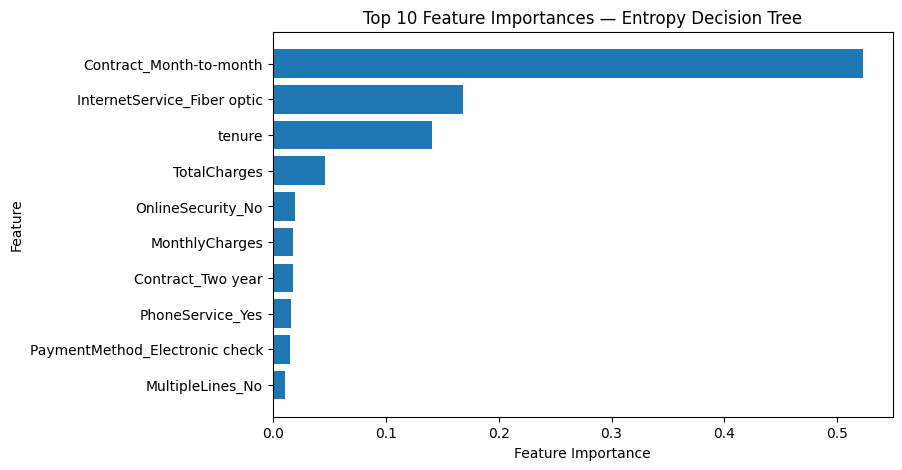

In [59]:
feature_importance=pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":entropy_model.feature_importances_
})
feature_importance=feature_importance.sort_values(by="Importance",ascending=False)
print(feature_importance.head(10))
top_features = feature_importance.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances — Entropy Decision Tree")
plt.show()

# Task 19 interpretation
The feature importance analysis shows that Contract_Month-to-month was the most important feature in the entropy-based Decision Tree, with an importance of 0.5229. The next most important features were InternetService_Fiber optic (0.1683) and tenure (0.1411). Other relatively important features included TotalCharges, OnlineSecurity_No, and MonthlyCharges. These importance values indicate which features the tree relied on most for its decisions; they do not imply that these features directly cause customer churn.

# Task 20
The feature importance results are broadly consistent with the patterns investigated during the exploratory data analysis in Lab 2. Contract type was particularly important in the Decision Tree, with Contract_Month-to-month having the highest importance, suggesting that contract characteristics are strongly useful for distinguishing churn from non-churn customers. InternetService_Fiber optic was the second most important feature, showing that internet service type also provides useful predictive information. tenure was another highly important feature, which is reasonable because it represents how long a customer has remained with the company. TotalCharges and MonthlyCharges also appeared among the more important features, indicating that billing-related information contributes to the model's predictions. Overall, the ML results provide predictive evidence that is consistent with the relationships explored during Lab 2 EDA, although feature importance does not establish that any feature directly causes churn.

# Part 8:Conclusion & Next Steps

# Task 21
Firstly a baseline Decision Tree classifier was developed to predict customer churn using the cleaned Telco customer dataset. The unrestricted tree reached approximately 99.77% training accuracy but only 71.53% test accuracy, indicating strong overfitting. Testing different maximum depths showed that max_depth=5 provided the best test accuracy (79.43%) while maintaining a much smaller train-test gap. Then we compared Gini and entropy criteria at depth 5, the entropy model achieved a slightly lower accuracy of 79.10% but higher recall (62.10%) and F1-score (61.10%), making it a strong choice for identifying potential churners. Feature importance showed that Contract_Month-to-month, InternetService_Fiber optic, and tenure were the most influential encoded features in the final model.

# Task 22
Possible next steps if I had time would be, comparing the Decision Tree with other classification algorithms to determine whether better predictive performance can be achieved. and because the Churn target is imbalanced, class-weighting or resampling techniques could also be investigated to improve the identification of churners. Additional Decision Tree hyperparameters, such as minimum samples per split or leaf, could be tuned to further control overfitting.


# Task 23

In [60]:
data = {
    "Outlook": [
        "Sunny", "Sunny", "Overcast", "Rain",
        "Rain", "Rain", "Overcast", "Sunny",
        "Sunny", "Rain", "Sunny", "Overcast",
        "Overcast", "Rain"
    ],
    "Temperature": [
        "Hot", "Hot", "Hot", "Mild",
        "Cool", "Cool", "Cool", "Mild",
        "Cool", "Mild", "Mild", "Mild",
        "Hot", "Mild"
    ],
    "Humidity": [
        "High", "High", "High", "High",
        "Normal", "Normal", "Normal", "High",
        "Normal", "Normal", "Normal", "High",
        "Normal", "High"
    ],
    "Wind": [
        "Weak", "Strong", "Weak", "Weak",
        "Weak", "Strong", "Strong", "Weak",
        "Weak", "Weak", "Strong", "Strong",
        "Weak", "Strong"
    ],
    "Play": [
        "No", "No", "Yes", "Yes",
        "Yes", "No", "Yes", "No",
        "Yes", "Yes", "Yes", "Yes",
        "Yes", "No"
    ]
}
play_df = pd.DataFrame(data)

print(play_df)

def entropy(target):
    counts = target.value_counts()
    probabilities = counts / len(target)

    entropy_value = 0

    for p in probabilities:
        entropy_value -= p * np.log2(p)

    return entropy_value


def information_gain(df, feature, target):
    total_entropy = entropy(df[target])

    weighted_entropy = 0

    for value in df[feature].unique():
        subset = df[df[feature] == value]

        weight = len(subset) / len(df)

        subset_entropy = entropy(subset[target])

        weighted_entropy += weight * subset_entropy

    gain = total_entropy - weighted_entropy

    return gain
def find_best_feature(df, features, target):

    best_feature = None
    best_gain = -1

    print("\nInformation Gain:")

    for feature in features:

        gain = information_gain(df, feature, target)

        print(f"{feature}: {gain:.4f}")

        if gain > best_gain:
            best_gain = gain
            best_feature = feature

    print(f"Best feature: {best_feature}")
    print(f"Best information gain: {best_gain:.4f}")

    return best_feature


def id3(df, features, target, level=0):


    target_values = df[target]



    if len(target_values.unique()) == 1:

        return target_values.iloc[0]


  

    if len(features) == 0:

        return target_values.mode()[0]


    # Find best feature
    best_feature = find_best_feature(
        df,
        features,
        target
    )


  
    tree = {
        best_feature: {}
    }


 
    remaining_features = [
        feature for feature in features
        if feature != best_feature
    ]


   
    for value in df[best_feature].unique():

        subset = df[df[best_feature] == value]

        print(
            "  " * level +
            f"Branch: {best_feature} = {value}"
        )

       
        if len(subset) == 0:

            tree[best_feature][value] = target_values.mode()[0]

        else:

            tree[best_feature][value] = id3(
                subset,
                remaining_features,
                target,
                level + 1
            )

    return tree



features = [
    "Outlook",
    "Temperature",
    "Humidity",
    "Wind"
]

target = "Play"

print("\nInitial Entropy:")
print(f"{entropy(play_df[target]):.4f}")

print("\nBuilding ID3 Decision Tree...")

tree = id3(
    play_df,
    features,
    target
)

print("\nFinal ID3 Decision Tree:")
print(tree)

     Outlook Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3       Rain        Mild     High    Weak  Yes
4       Rain        Cool   Normal    Weak  Yes
5       Rain        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9       Rain        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13      Rain        Mild     High  Strong   No

Initial Entropy:
0.9403

Building ID3 Decision Tree...

Information Gain:
Outlook: 0.2467
Temperature: 0.0292
Humidity: 0.1518
Wind: 0.0481
Best feature: Outlook
Best information gain: 0.2467
Branch: Outlook = Sunny

Information Gain:
Temperature: 0.5710
Humidity: 0.9710
Wind: 0.0200
Best feat

# Task 23 interpretation
In this task, I implemented the ID3 Decision Tree algorithm without using a built-in machine learning library. The algorithm uses entropy to measure how mixed the target values are and Information Gain to determine which feature provides the best split. For the Play Badminton dataset, the initial entropy was approximately 0.9403, and Outlook produced the highest Information Gain among the available features, so it was selected as the first split. The same process was then repeated for the smaller subsets created by each branch. This shows how ID3 gradually builds a decision tree by choosing the feature that provides the most useful separation between the classes.

# Submission Checklist

- [x] Student information is provided at the top of the notebook.
- [x] Task 1 — Dataset loaded and verified.
- [x] Task 2 — ML problem and business relevance explained.
- [x] Task 3 — Features and target prepared.
- [x] Task 4 — Categorical features converted to numeric form.
- [x] Task 5 — Numeric data and missing values verified.
- [x] Task 6 — Train/test split performed with stratification.
- [x] Task 7 — Training and testing shapes reported.
- [x] Task 8 — Baseline Decision Tree trained and predictions generated.
- [x] Task 9 — Baseline tree depth reported.
- [x] Task 10 — Accuracy, precision, recall, and F1-score reported.
- [x] Task 11 — Confusion matrix plotted and interpreted.
- [x] Task 12 — Appropriate evaluation metrics discussed for class imbalance.
- [x] Task 13 — Training and test performance compared to identify overfitting.
- [x] Task 14 — Multiple tree depths evaluated.
- [x] Task 15 — Training and test accuracy compared across tree depths.
- [x] Task 16 — Final tree depth selected based on evidence.
- [x] Task 17 — Final Gini Decision Tree evaluated.
- [x] Task 18 — Entropy Decision Tree evaluated and compared.
- [x] Task 19 — Feature importance calculated and interpreted.
- [x] Task 20 — Important features connected to Lab 2 EDA findings.
- [x] Task 21 — Final conclusion provided.
- [x] Task 22 — Possible next steps discussed without implementation.
- [x] Task 23 — ID3 implemented from scratch using entropy and Information Gain.
